# 1 — Imports & Setup

In [2]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
from torch.amp import GradScaler, autocast
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

# Auto-detect project root
root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor
from Models.ConvNeXT import ConvNeXT

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Device  : cuda
PyTorch : 2.11.0+cu130


# 2 — Hyperparameters (Baseline)

In [3]:
EPOCHS       = 40
BATCH_SIZE   = 16
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.4
HEAD_DEPTH   = 1
NUM_CLASSES  = 28

print(f"Epochs      : {EPOCHS}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"LR          : {LR}")
print(f"Dropout     : {DROPOUT}")
print(f"Head depth  : {HEAD_DEPTH}")


Epochs      : 40
Batch size  : 16
LR          : 0.0001
Dropout     : 0.4
Head depth  : 1


# 3 — Data Pipeline (ConvNeXt Baseline Augmentation)
Uses the transformer‑light baseline augmentation:
PadToSquare
RandomResizedCrop (0.6–1.0)
flips
rotations
ColorJitter
GaussianBlur
RandomErasing
WaRP‑C mean/std
WeightedRandomSampler
minority augmentation
NO MixUp
NO TrivialAugmentWide (baseline only)

In [4]:
pp = WaRPPreprocessor(
    raw_root       = root / "Dataset/raw/WaRP-C",
    processed_root = root / "Dataset/processed",
    stats_file     = root / "Dataset/dataset_stats.json",
    batch_size     = BATCH_SIZE,
    num_workers    = 4,
)

train_loader, test_loader = pp.get_loaders(model_type="convnext")

CLASS_NAMES = sorted(
    d.name for d in (root / "Dataset/processed/train").iterdir() if d.is_dir()
)

print(f"Classes       : {len(CLASS_NAMES)}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")


[get_loaders] model='convnext'
  sampler=True  minority_aug=True  mixup=True  pipeline='transformer'
  train=547 batches  test=97 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 547
Test  batches : 97


# 4 — Loss Function

In [5]:
class_weights = pp.get_class_weights(device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Loss: CrossEntropyLoss + class weights")


Loss: CrossEntropyLoss + class weights


# 5 — Model (ConvNeXt Baseline)

In [6]:
model = ConvNeXT(
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
    head_depth  = HEAD_DEPTH,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
)

scaler = GradScaler(enabled=(DEVICE == "cuda"))

# Sanity check
with torch.no_grad():
    out = model(torch.zeros(2, 3, 384, 384).to(DEVICE))
print("Output shape:", out.shape)


Output shape: torch.Size([2, 28])


# 6 — Training Loop (No Scheduler)

In [7]:
train_losses, train_accs, test_accs = [], [], []
best_acc = 0.0

print(f"Starting {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):

    model.train()
    ep_loss = correct = total = 0
    t0 = time.time()

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        optimizer.zero_grad()

        with autocast(device_type="cuda", enabled=(DEVICE == "cuda")):
            logits = model(imgs)
            loss   = criterion(logits, lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        ep_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total * 100

    # Evaluate
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    test_acc = correct / total * 100

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), root / "Models/weights/convnext_baseline.pth")
        flag = " ← best"
    else:
        flag = ""

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"loss={train_loss:.4f} | train={train_acc:.2f}% | "
          f"test={test_acc:.2f}% | best={best_acc:.2f}% | "
          f"{time.time()-t0:.1f}s{flag}")


Starting 40 epochs...

Epoch   1/40 | loss=2.7881 | train=9.41% | test=5.67% | best=5.67% | 26.8s ← best
Epoch   2/40 | loss=2.1157 | train=23.21% | test=15.15% | best=15.15% | 11.3s ← best
Epoch   3/40 | loss=1.8016 | train=31.73% | test=22.18% | best=22.18% | 11.4s ← best
Epoch   4/40 | loss=1.6143 | train=37.77% | test=25.34% | best=25.34% | 11.4s ← best
Epoch   5/40 | loss=1.4773 | train=41.36% | test=26.63% | best=26.63% | 11.4s ← best
Epoch   6/40 | loss=1.4570 | train=43.35% | test=30.30% | best=30.30% | 11.4s ← best
Epoch   7/40 | loss=1.3230 | train=45.17% | test=32.75% | best=32.75% | 11.4s ← best
Epoch   8/40 | loss=1.2876 | train=46.68% | test=31.85% | best=32.75% | 11.2s
Epoch   9/40 | loss=1.2357 | train=48.66% | test=33.59% | best=33.59% | 11.4s ← best
Epoch  10/40 | loss=1.2073 | train=48.75% | test=34.04% | best=34.04% | 11.7s ← best
Epoch  11/40 | loss=1.2130 | train=49.04% | test=37.72% | best=37.72% | 12.5s ← best
Epoch  12/40 | loss=1.1753 | train=50.13% | test=37.

# 7 — Training Curves

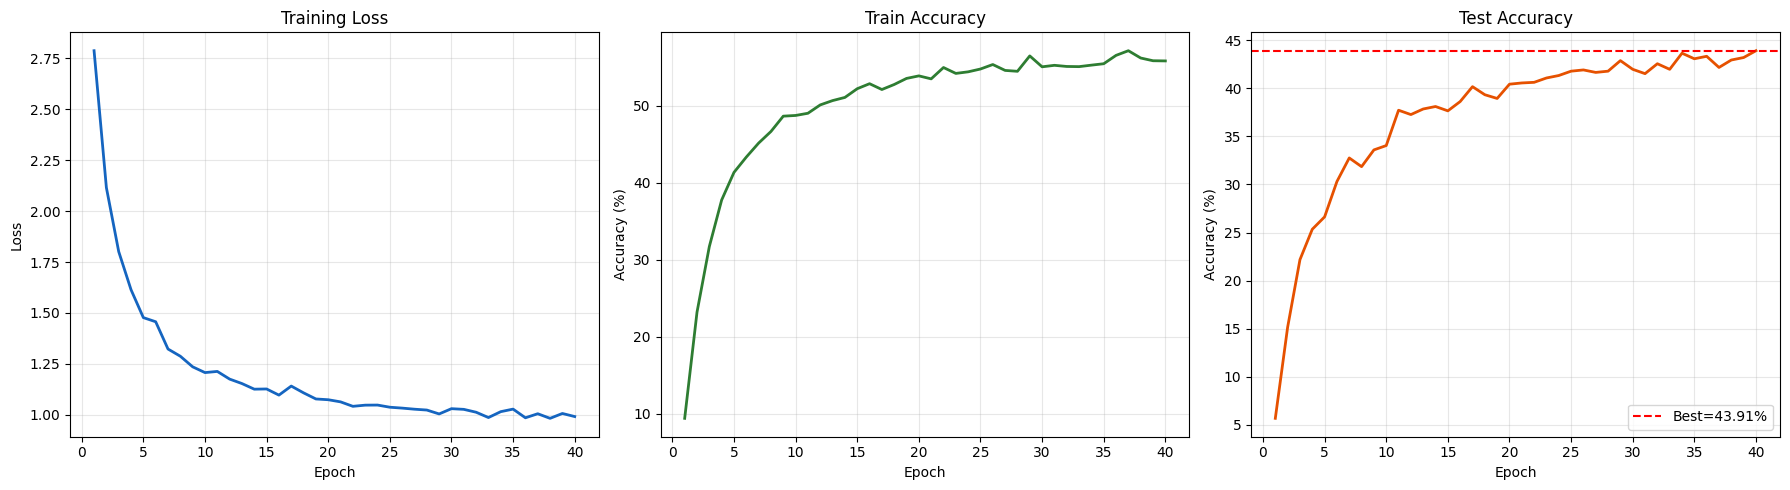

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, train_losses, "#1565C0", lw=2)
axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(ep, train_accs, "#2E7D32", lw=2)
axes[1].set(title="Train Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].grid(alpha=0.3)

axes[2].plot(ep, test_accs, "#E65100", lw=2)
axes[2].axhline(best_acc, color="red", ls="--", label=f"Best={best_acc:.2f}%")
axes[2].set(title="Test Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 8 — Evaluation (Final Metrics)

In [9]:
model.load_state_dict(torch.load(root / "Models/weights/convnext_baseline.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

acc  = (y_pred == y_true).mean() * 100
f1   = f1_score(y_true, y_pred, average="macro") * 100
w_f1 = f1_score(y_true, y_pred, average="weighted") * 100
prec = precision_score(y_true, y_pred, average="macro") * 100
rec  = recall_score(y_true, y_pred, average="macro") * 100

print("="*50)
print("  ConvNeXt Baseline — Final Metrics")
print("="*50)
print(f"  Accuracy      : {acc:.2f}%")
print(f"  Macro F1      : {f1:.2f}%")
print(f"  Weighted F1   : {w_f1:.2f}%")
print(f"  Precision     : {prec:.2f}%")
print(f"  Recall        : {rec:.2f}%")
print("="*50)


  ConvNeXt Baseline — Final Metrics
  Accuracy      : 43.91%
  Macro F1      : 47.80%
  Weighted F1   : 44.41%
  Precision     : 53.76%
  Recall        : 55.13%


# 9 — Confusion Matrix

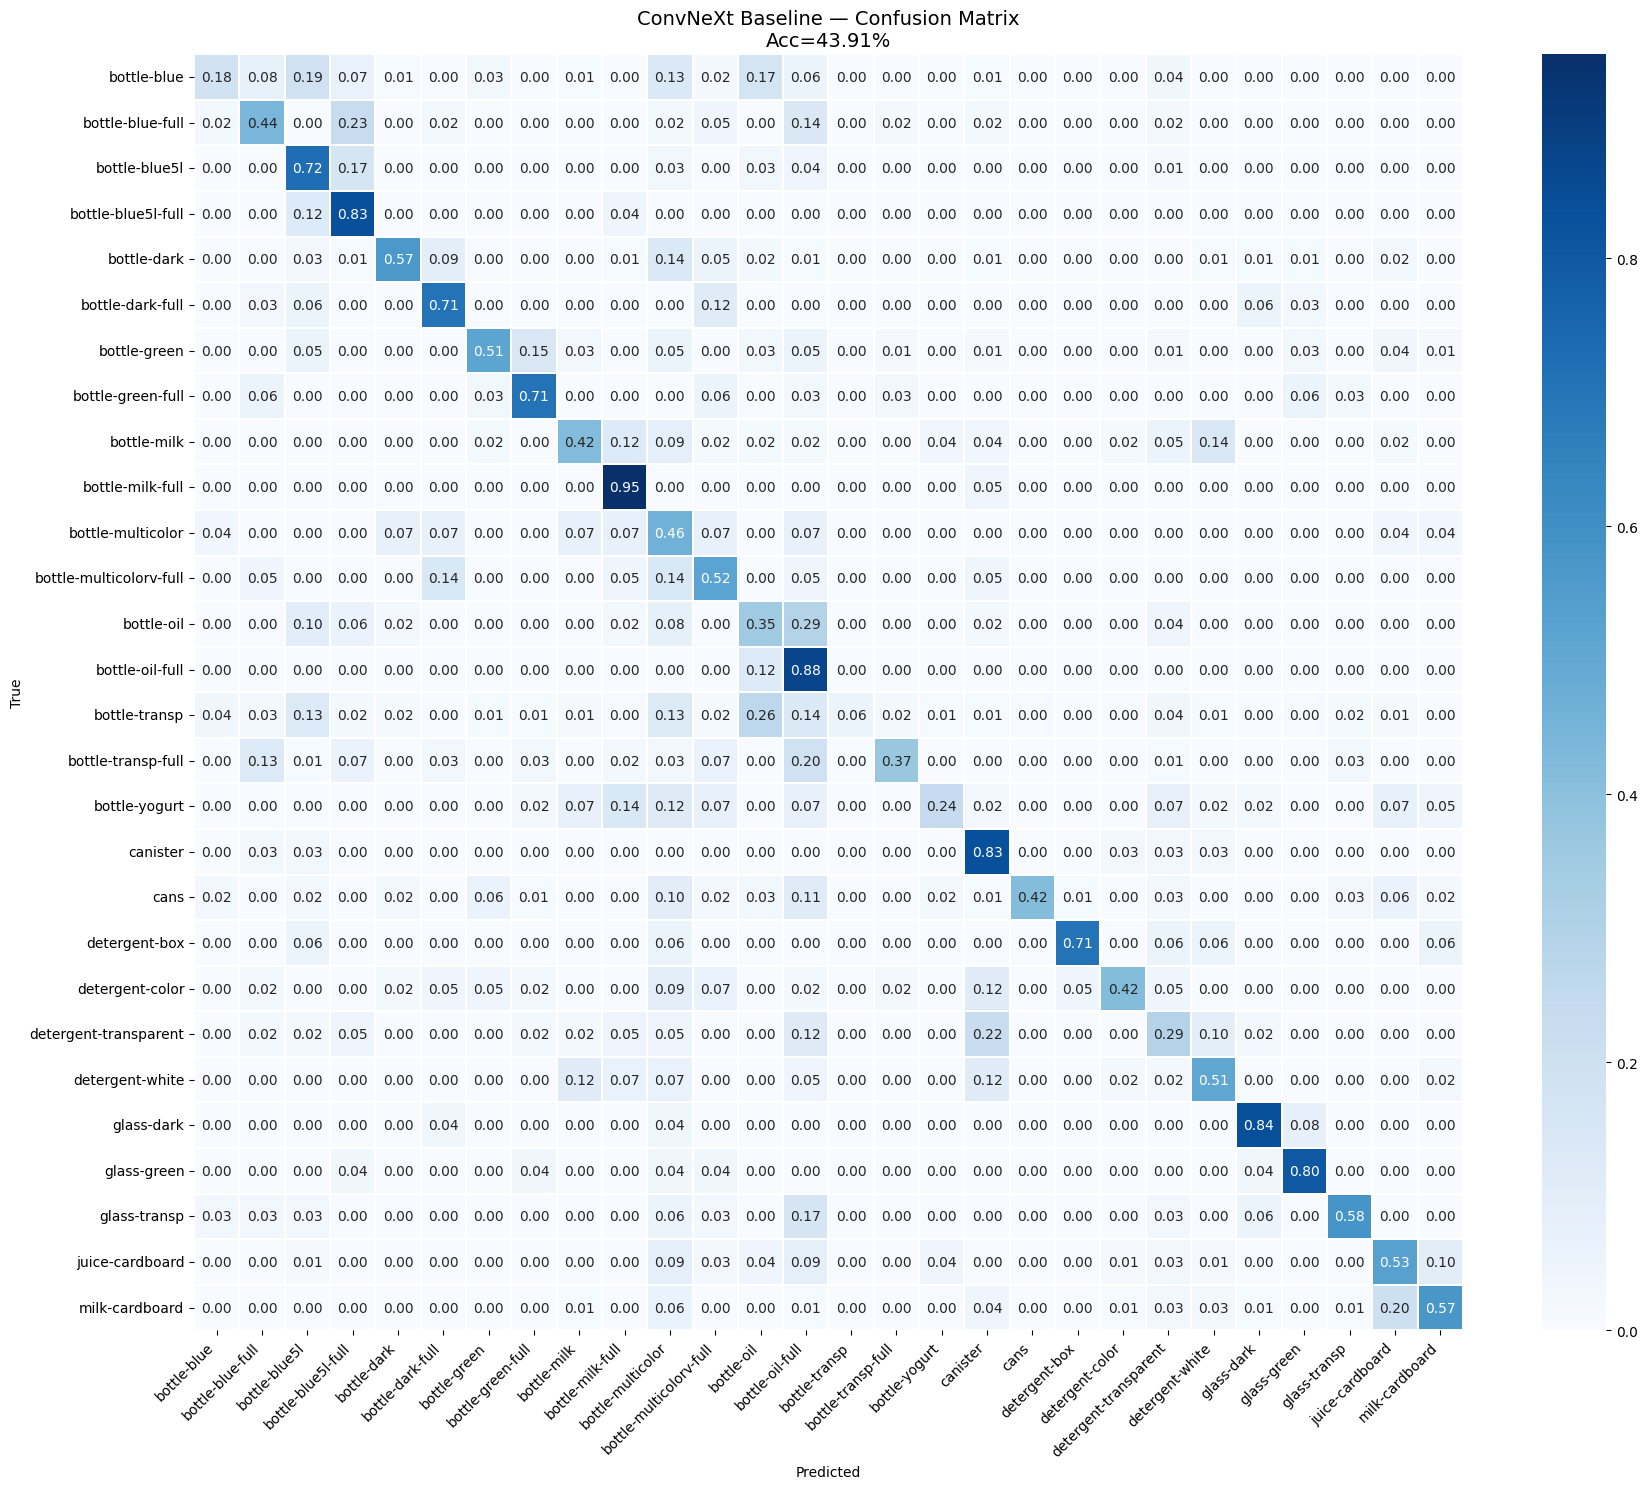

In [10]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3
)
ax.set_title(f"ConvNeXt Baseline — Confusion Matrix\nAcc={acc:.2f}%", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 10 — Summary

In [11]:
print("="*60)
print("  ConvNeXt Baseline — Summary")
print("="*60)
print(f"  Pretrained       : ImageNet‑1K")
print(f"  Epochs           : {EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  LR               : {LR}")
print(f"  Dropout          : {DROPOUT}")
print(f"  Head depth       : {HEAD_DEPTH}")
print(f"  Scheduler        : None (baseline)")
print(f"  Best test acc    : {best_acc:.2f}%")
print(f"  Final accuracy   : {acc:.2f}%")
print(f"  Macro F1         : {f1:.2f}%")
print(f"  Weighted F1      : {w_f1:.2f}%")
print("="*60)


  ConvNeXt Baseline — Summary
  Pretrained       : ImageNet‑1K
  Epochs           : 40
  Batch size       : 16
  LR               : 0.0001
  Dropout          : 0.4
  Head depth       : 1
  Scheduler        : None (baseline)
  Best test acc    : 43.91%
  Final accuracy   : 43.91%
  Macro F1         : 47.80%
  Weighted F1      : 44.41%
